In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.optimize as opt
import scipy.integrate as integrate

%matplotlib ipympl

# #1 Expectation Values

We want to be able to estimate expectation values drawn from complicated probability distributions over many, many dimensions. But let's start smaller and simpler. The expectation value of an observable $\mathcal{O}$ in one dimension can be written as 
$$ \langle \mathcal{O}\rangle = \frac{1}{\mathcal{Z}}\int_{-\infty}^{\infty} dx\, \mathcal{O}(x) p(x), $$
where $p(x)$ is our probability distribution, $\mathcal{O}(x)$ is our observable and we have introduced $\mathcal{Z}$ defined as
$$ \mathcal{Z} = \int_{-\infty}^{\infty}dx\, p(x),$$
in the case that the probability distribution $p(x)$ isn't normalised to 1. This is straightforward when $p(x)$ is known, $\mathcal{O}(x)$ is known, and their product is analytically integrable. 

Let's consider a simple case from a first year course on Quantum Mechanics. We want to estimate the average position of a particle in a harmonic oscillator potential,
$$ V(x) = \frac{1}{2}m\omega^2 x^2.$$
The probability density of the particle is given by the squared modulus of the wavefunction, $\psi(x)$,
$$ p(x) = |\psi(x)|^2, $$
where if we consider the ground state wavefunction,
$$ \psi_0(x) = \left( \frac{m\omega}{\pi \hbar}\right)^{1/4} \exp\left( -\frac{m\omega}{2\hbar}x^2\right),$$
then our probability density function is simply
$$ p(x) = \left( \frac{m\omega}{\pi\hbar}\right)^{1/2} \exp\left( \frac{m\omega}{\hbar}x^2\right). $$
Using the position operator $\hat{x}=x$, the average position becomes
$$ \langle x\rangle = \left( \frac{m\omega}{\pi\hbar}\right)^{1/2}\int_{-\infty}^\infty dx\, x \exp\left( \frac{m\omega}{\hbar}x^2\right), $$
where, as our $\psi_0(x)$ was already normalised, $\mathcal{Z}=1$. This integral turns out to be zero due to symmetry, but the expectation value of $x^2$ does not vanish,
$$ \begin{split}\langle x^2\rangle &= \left( \frac{m\omega}{\pi\hbar}\right)^{1/2}\int_{-\infty}^\infty dx\, x^2 \exp\left( \frac{m\omega}{\hbar}x^2\right) \\ &= \frac{\hbar}{2m\omega}.\end{split}$$
The point being, that we can evaluate these types of integrals by hand and get nice, analytic results. But potentials which have nice, closed form expressions for their wavefunctions and nice, analytic results for their expectation values are rare. Realistically, the Schrodinger equation would have to be solved numerically, and those numerical solutions fed into the expectation value integral.

## Estimation of $\pi$ with Monte Carlo

This is a classic introduction to Monte Carlo estimation. Monte Carlo methods get their name from the Monte Carlo casino in Monaco, and so the method is based upon random chance.

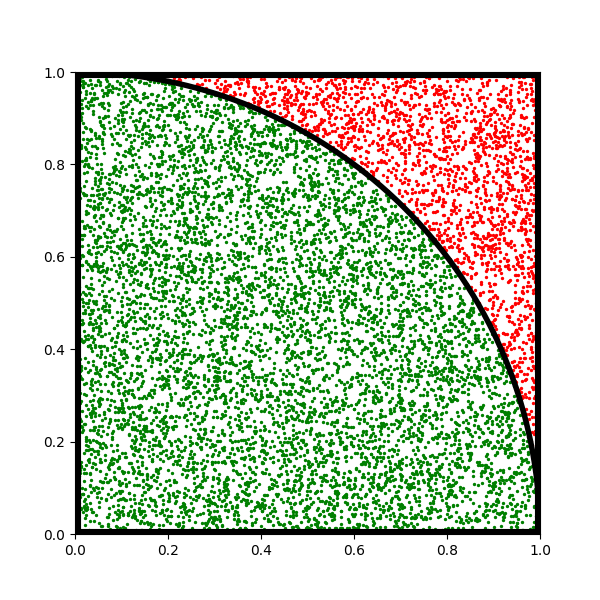

pi estimate = 3.1456


In [2]:
num_guesses = 1e4

random_points = np.random.uniform(size=(int(num_guesses),2))


inside_circle = np.array([x for x in random_points if (x[0]**2 + x[1]**2 < 1)])
outside_circle = np.array([x for x in random_points if (x[0]**2 + x[1]**2 > 1)])


plt.figure(figsize = (6,6))
plt.plot(np.linspace(0,1,250), np.sqrt(1-np.linspace(0,1,250)**2), c = 'k', lw = 4)
plt.vlines([0,1], 0, 1, color = 'k', lw = 8)
plt.hlines([0,1], 0, 1, color = 'k', lw = 8)
plt.scatter(inside_circle[:,0],inside_circle[:,1], c = 'g', s = 2)
plt.scatter(outside_circle[:,0],outside_circle[:,1], c = 'r', s = 2)
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()


pi_estimate = 4 * np.shape(inside_circle)[0] / num_guesses
print(f'pi estimate = {pi_estimate}')

Now that isn't too bad, we've got an estimate of $\pi$ just by drawing random numbers. But you should always be wary of just quoting numbers - it's worth asking "how sure are you in this number?" So we want a means to quantify our uncertainty in our quoted estimate. One simple way is to just repeat the simulation a number of times and see how much our estimate varies over those samples.

Warning! The run time of the code will increase as you increase the num_simulations and num_guesses.

In [3]:
def single_estimate(num_guesses):
    random_points = np.random.uniform(size=(int(num_guesses),2))
    inside_circle = np.array([x for x in random_points if (x[0]**2 + x[1]**2 < 1)])
    pi_estimate = 4 * np.shape(inside_circle)[0]/num_guesses
    return pi_estimate

num_simulations = 1000
num_guesses = 1e4

pi_vals = np.zeros(num_simulations)

for i in range(num_simulations):
    pi_vals[i] = single_estimate(num_guesses)
    
print(f'pi estimate = {np.average(pi_vals): .6f} +/- {np.std(pi_vals):.6f}')

pi estimate =  3.141894 +/- 0.017114


We can investigate how our statistical uncertainty varies with the number of samples we draw and the number of guesses we make in each simulation

In [4]:
simulation_values_variable = [10, 100, 1000, 1e4, 1e5]
num_guesses_fixed = 100
num_guesses_variable = [100,1000,1e4,1e5]
simulation_values_fixed = 100

sim_averages = np.zeros(len(simulation_values_variable))
sim_stds = np.zeros(len(simulation_values_variable))

for isim, sim_val in enumerate(simulation_values_variable):
    temp_ests = np.zeros(int(sim_val))
    for i in range(int(sim_val)):
        temp_ests[i] = single_estimate(num_guesses_fixed)
    sim_averages[isim] = np.average(temp_ests)
    sim_stds[isim] = np.std(temp_ests)
    
guesses_averages = np.zeros(len(num_guesses_variable))
guesses_stds = np.zeros(len(num_guesses_variable))

for iguesses, guess_val in enumerate(num_guesses_variable):
    temp_ests = np.zeros(int(simulation_values_fixed))
    for i in range(int(simulation_values_fixed)):
        temp_ests[i] = single_estimate(num_guesses_variable[iguesses])
    guesses_averages[iguesses] = np.average(temp_ests)
    guesses_stds[iguesses] = np.std(temp_ests)


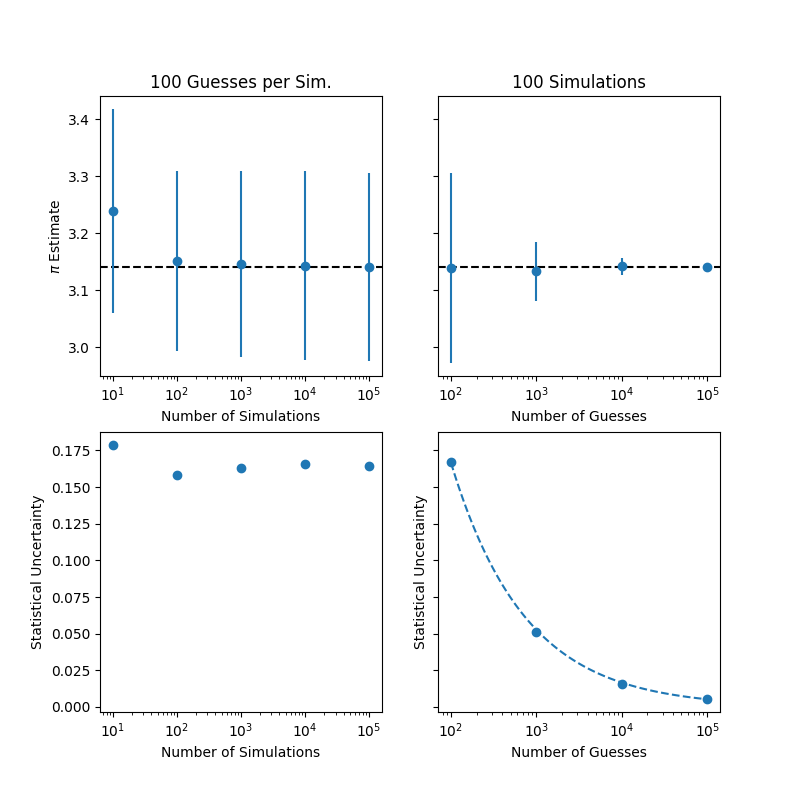

In [5]:
def statistical_uncertainty_model(n, a):
    return a/np.sqrt(n)

fit_params,_ = opt.curve_fit(statistical_uncertainty_model, num_guesses_variable, guesses_stds, p0=[1])
x_cont = np.logspace(2,5,100)

fig, axs = plt.subplots(nrows=2,ncols=2, sharey= 'row', figsize = (8,8))
axs[0,0].axhline(np.pi, ls = '--', c = 'k')
axs[0,0].errorbar(simulation_values_variable, sim_averages, yerr = sim_stds, marker = 'o', ls = 'none')
axs[0,0].set_xscale('log')
axs[0,0].set_xlabel('Number of Simulations')
axs[0,0].set_title('100 Guesses per Sim.')
axs[0,0].set_ylabel(r'$\pi$ Estimate')
axs[0,1].axhline(np.pi, ls = '--', c = 'k')
axs[0,1].errorbar(num_guesses_variable, guesses_averages, yerr = guesses_stds, marker = 'o', ls = 'none')
axs[0,1].set_xscale('log')
axs[0,1].set_xlabel('Number of Guesses')
axs[0,1].set_title(r'100 Simulations')
axs[1,0].scatter(simulation_values_variable, sim_stds)
axs[1,0].set_ylabel('Statistical Uncertainty')
axs[1,0].set_xlabel('Number of Simulations')
axs[1,0].set_xscale('log')
axs[1,1].scatter(num_guesses_variable, guesses_stds)
axs[1,1].plot(x_cont, statistical_uncertainty_model(x_cont,*fit_params), ls = '--')
axs[1,1].set_ylabel('Statistical Uncertainty')
axs[1,1].set_xlabel('Number of Guesses')
axs[1,1].set_xscale('log')
plt.show()

So we can see that when we increase the number of simulations but hold the number of guesses fixed, the average of our simulations does converge to the value of $\pi$, however there is minimal benefit in our statistical uncertainty. Contrast that with increasing the number of guesses per simulation and holding the number of simulations fixed and we see a dramatic improvement in our statistical uncertainty.

In the bottom right plot, I've included a fit model of the statistical uncertainty which shows that the uncertainty scales as approximately
$$ \sigma \propto \frac{A}{\sqrt{N_{\text{guesses}}}},$$
with $A$ some constant value determined by fitting to the data.

## Estimating Integrals with Monte Carlo

Now let's graduate from estimating $\pi$ with Monte Carlo methods to evaluating 1D integrals with Monte Carlo. As before, let's first evaluate an integral we should all know:
$$ I = \int_0^\pi dx\, \sin(x) = 2.$$

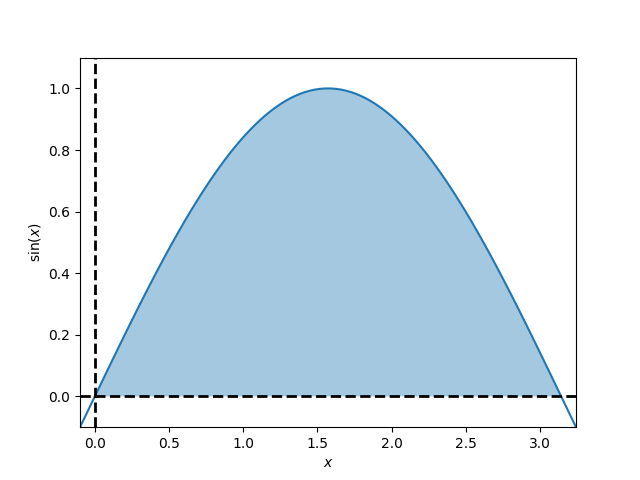

In [6]:
plt.figure()
plt.plot(np.linspace(-0.1,np.pi+0.1,100), np.sin(np.linspace(-0.1,np.pi+0.1,100)))
plt.fill_between(np.linspace(0,np.pi,100), np.zeros(100), np.sin(np.linspace(0,np.pi,100)), alpha = 0.4)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin(x)$')
plt.axhline(0, ls = '--', c = 'k', lw = 2)
plt.axvline(0, ls = '--', c = 'k', lw = 2)
plt.xlim(-0.1,np.pi+0.1)
plt.ylim(-0.1,1.1)
plt.show()

In the conventional picture of integration, we are summing rectangles of infinitesimal width and height equal to the function evaluated at $x$. Therefore, we could randomly sample points along the region of integration, evaluate the function at these points, and average these random guesses.
$$ \langle I \rangle = \frac{b-a}{N}\sum_{i=1}^N f(x_i)$$

In [7]:
num_guesses = 1000
random_x_points = np.random.uniform(0,np.pi,num_guesses)
function_at_points = np.sin(random_x_points)
int_estimate = (np.pi/num_guesses)*np.sum(function_at_points)
print(f'Estimate of sin(x) integral = {int_estimate: .5f}')

Estimate of sin(x) integral =  2.06191


Again, we have obtained a very close estimate to the true value of the integral, just by pulling random numbers from our integration region. Using lessons from our estimates of $\pi$, if we repeat this calculation multiple times, we can obtain an estimate for our uncertainty in the integral.

In [8]:
def single_integral_estimate(num_guesses):
    random_x_points = np.random.uniform(0,np.pi,num_guesses)
    function_at_points = np.sin(random_x_points)
    int_estimate = (np.pi/num_guesses)*np.sum(function_at_points)
    return int_estimate

num_simulations = 1000
integral_estimates = np.zeros(num_simulations)
for i in range(num_simulations):
    integral_estimates[i] = single_integral_estimate(1000)
average_estimate = np.average(integral_estimates)
std_estimate = np.std(integral_estimates)

print(f'Integral estimate = {average_estimate: .6f} +/- {std_estimate:.6f}')

Integral estimate =  1.998782 +/- 0.030634


Now let's see how our statistical uncertainty in the integral estimate varies with the number of guesses per simulation.

In [9]:
num_guesses_variable = [100,1000,1e4,1e5]
num_simulations_fixed = 100

average_integral_estimates = np.zeros(len(num_guesses_variable))
std_integral_estimates = np.zeros(len(num_guesses_variable))
for iguesses, num_guesses in enumerate(num_guesses_variable):
    temp_estimates = np.zeros(num_simulations_fixed)
    for i in range(num_simulations_fixed):
        temp_estimates[i] = single_integral_estimate(int(num_guesses))
    average_integral_estimates[iguesses] = np.average(temp_estimates)
    std_integral_estimates[iguesses] = np.std(temp_estimates)

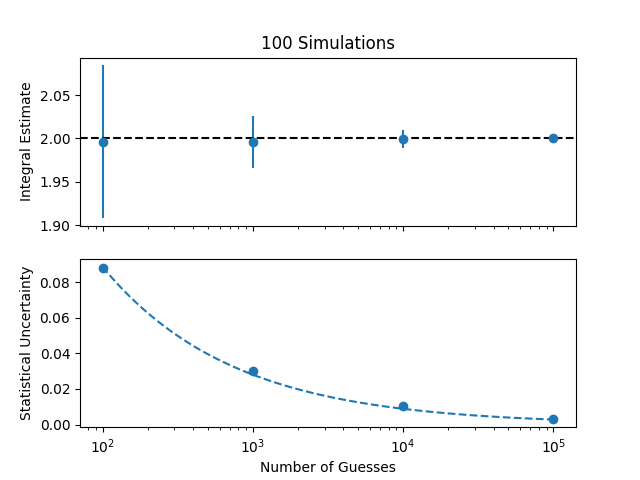

In [10]:
fit_params,_ = opt.curve_fit(statistical_uncertainty_model, num_guesses_variable, std_integral_estimates, p0 = 1)
x_cont = np.logspace(2,5,100)

fig, axs = plt.subplots(nrows=2,ncols=1,sharex=True)
axs[0].errorbar(num_guesses_variable, average_integral_estimates, yerr = std_integral_estimates, marker = 'o', ls = 'none')
axs[0].axhline(2, ls = '--', c ='k')
axs[0].set_xscale('log')
axs[0].set_ylabel('Integral Estimate')
axs[0].set_title('100 Simulations')
axs[1].scatter(num_guesses_variable, std_integral_estimates)
axs[1].plot(x_cont, statistical_uncertainty_model(x_cont,*fit_params), ls = '--')
axs[1].set_xscale('log')
axs[1].set_xlabel('Number of Guesses')
axs[1].set_ylabel('Statistical Uncertainty')
plt.show()


As expected, the statistical uncertainty decreases with increasing numbers of guesses per simulation, and this can be well approximated by a $1/\sqrt{N}$ function.

Now, what if we wanted to integrate a less-well-behaved function? Let us consider the Gaussian function $e^{-x^2}$.
This function does not have a defined indefinite integral, but its definite integral is known:
$$ \int_{-\infty}^{\infty}dx\, e^{-x^2}=\sqrt{\pi}$$

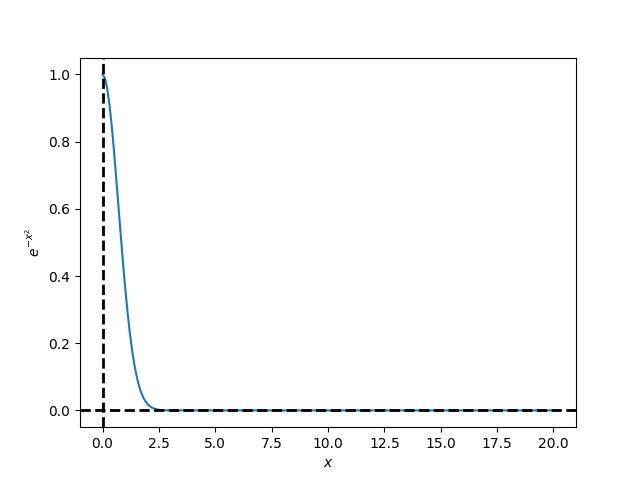

In [45]:
x = np.linspace(0,20,200)
plt.figure()
plt.plot(x, np.exp(-x**2))
plt.axhline(0,ls = '--',c='k',lw =2)
plt.axvline(0,ls = '--',c='k',lw =2)
plt.xlabel(r'$x$')
plt.ylabel(r'$e^{-x^2}$')
plt.show()

But it shouldn't matter that it's not immediately obvious how to integrate this function by hand, right? We can just use our Monte Carlo methods to numerically estimate the value with sufficient precision. Note that as we are evaluating an integral over an infinite bound, we cannot technically sample over this whole region. We need to define an upper bound on our sampling region that is physically reasonable.

In [53]:
def gauss_integral_single_estimate(num_guesses):
    upper_bound = 20
    x_points = np.random.uniform(-upper_bound,upper_bound,num_guesses)
    function_at_points = np.exp(-x_points**2)
    int_estimate = (2*upper_bound/num_guesses)*np.sum(function_at_points)
    return int_estimate

num_guesses_variable = [100,1000,1e4,1e5]
num_simulations = 100

average_gauss_integral = np.zeros(len(num_guesses_variable))
std_gauss_integral = np.zeros(len(num_guesses_variable))

for iguess,num_guesses in enumerate(num_guesses_variable):
    temp_estimates = np.zeros(num_simulations)
    for i in range(num_simulations):
        temp_estimates[i] = gauss_integral_single_estimate(int(num_guesses))
    average_gauss_integral[iguess] = np.average(temp_estimates)
    std_gauss_integral[iguess] = np.std(temp_estimates)

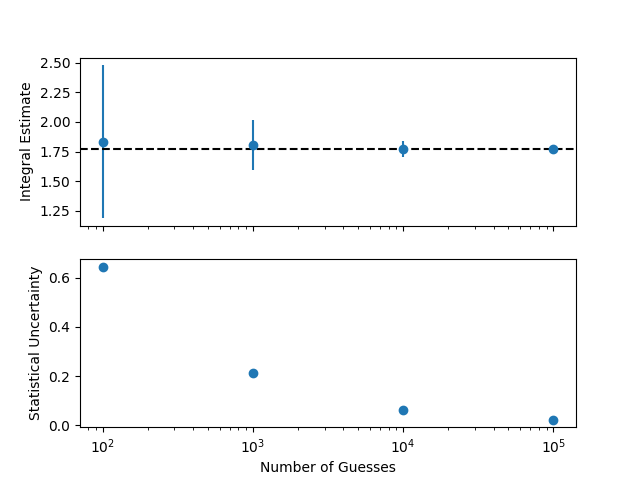

In [54]:
fig,axs = plt.subplots(nrows=2,ncols=1,sharex=True)
axs[0].errorbar(num_guesses_variable, average_gauss_integral, yerr = std_gauss_integral, marker = 'o', ls = 'none')
axs[0].axhline(np.sqrt(np.pi), ls = '--', c = 'k')
axs[0].set_ylabel('Integral Estimate')
axs[0].set_xscale('log')
axs[1].scatter(num_guesses_variable, std_gauss_integral)
axs[1].set_ylabel(r'Statistical Uncertainty')
axs[1].set_xscale('log')
axs[1].set_xlabel('Number of Guesses')
plt.show()


Now we see a problem, the uncertainty in our estimate is considerably larger than our previous Monte Carlo estimates.

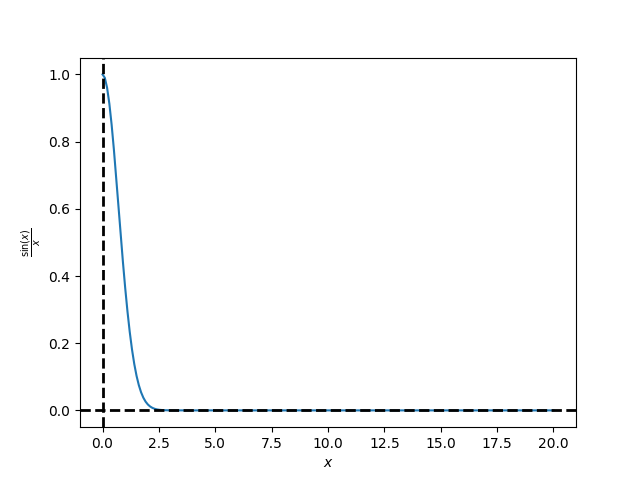

In [66]:
x = np.linspace(0,20,200)
gauss_data = np.exp(-x**2)
fig = plt.figure()
ax = plt.gca()
line = plt.plot(x, gauss_data)
color = line[-1].get_color()
plt.axhline(0,ls = '--',c='k',lw =2)
plt.axvline(0,ls = '--',c='k',lw =2)
plt.xlabel(r'$x$')
plt.ylabel(r'$\frac{\sin(x)}{x}$')

line, = ax.plot([], [], color = color, lw=2)

def init():
    line.set_data([], [])
    return line,

def update_integral_frame(frame):
    x_frame = x[:frame]
    y_frame = gauss_data[:frame]
    p = plt.fill_between(x_frame,y_frame,0, color = color, alpha=0.2)
    
    return p,

anim = animation.FuncAnimation(fig,update_integral_frame, init_func=init, 
                               frames = 200, interval=5, blit=False, repeat=False)

plt.show()

The reason for this large variance in our Monte Carlo estimate is encoded in our method - we sample uniformly over the integration region, however the contributions to the integral are not uniform over the region. A simple modification to our method is therefore proposed: sample more frequently in the regions that contribute more to the integral. We first have to define a sampling distribution which mimics the behaviour of our integral. One such distribution that has this behaviour is 
$$ q(x) = e^{-x}.$$

In [ ]:
def gauss_integral_single_weighted_estimate(num_guesses):
    u_points = np.random.uniform(0,1,num_guesses)
    x_points = np.log(1-u_points)
    function_at_points = np.exp(-x_points**2)*np.exp(-x_points)
    int_estimate = (2/num_guesses)*np.sum(function_at_points)
    return int_estimate

num_guesses_variable = [100,1000,1e4,1e5]
num_simulations = 100

average_weighted_gauss_integral = np.zeros(len(num_guesses_variable))
std_weighted_gauss_integral = np.zeros(len(num_guesses_variable))

for iguess,num_guesses in enumerate(num_guesses_variable):
    temp_estimates = np.zeros(num_simulations)
    for i in range(num_simulations):
        temp_estimates[i] = gauss_integral_single_weighted_estimate(int(num_guesses))
    average_weighted_gauss_integral[iguess] = np.average(temp_estimates)
    std_weighted_gauss_integral[iguess] = np.std(temp_estimates)

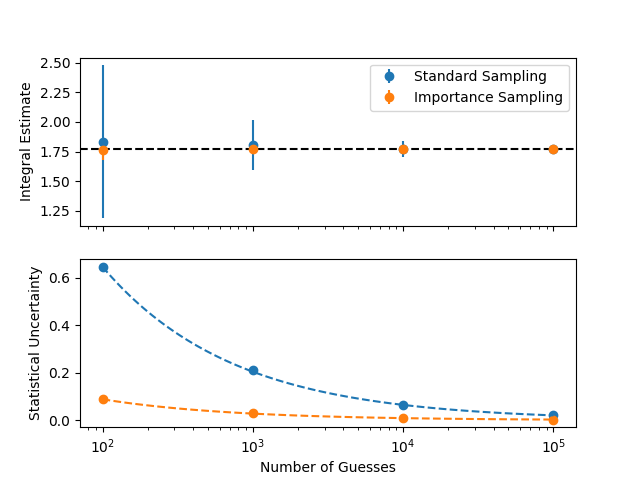

In [70]:
fit_params_unweighted,_ = opt.curve_fit(statistical_uncertainty_model, num_guesses_variable, std_gauss_integral, p0 = [1])
fit_params_weighted,_ = opt.curve_fit(statistical_uncertainty_model, num_guesses_variable, std_weighted_gauss_integral, p0 = [1])

fig,axs = plt.subplots(nrows=2,ncols=1,sharex=True)
axs[0].errorbar(num_guesses_variable, average_gauss_integral, yerr = std_gauss_integral, marker = 'o', ls = 'none',label = 'Standard Sampling')
axs[0].errorbar(num_guesses_variable, average_weighted_gauss_integral, yerr = std_weighted_gauss_integral, marker = 'o', ls = 'none', label = 'Importance Sampling')
axs[0].axhline(np.sqrt(np.pi), ls = '--', c = 'k')
axs[0].set_ylabel('Integral Estimate')
axs[0].set_xscale('log')
axs[0].legend()
axs[1].scatter(num_guesses_variable, std_gauss_integral)
axs[1].plot(x_cont, statistical_uncertainty_model(x_cont, *fit_params_unweighted), ls = '--')
axs[1].scatter(num_guesses_variable, std_weighted_gauss_integral)
axs[1].plot(x_cont, statistical_uncertainty_model(x_cont, *fit_params_weighted), ls = '--')
axs[1].set_ylabel(r'Statistical Uncertainty')
axs[1].set_xscale('log')
axs[1].set_xlabel('Number of Guesses')
plt.show()

This importance sampling has made a dramatic improvement on the uncertainty of our estimate - nearly an order of magnitude more precise.